



# Q. Analytical Derivation

## Question 1: Show that $x_k^- \sim \mathcal{N}(m_k^-, P_k^-)$

**Predicted Mean:**

$$m_k^- = \mathbb{E}[x_k^-] = \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}]$$
$$= A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}] = A_{k-1}m_{k-1} + 0 = A_{k-1}m_{k-1}$$

**Predicted Covariance:**

$$P_k^- = \text{Var}(x_k^-) = \text{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1})$$

Since $x_{k-1}^+$ and $w_{k-1}$ are independent:

$$= A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T$$

Since $x_{k-1}^+ \sim \mathcal{N}(m_{k-1}, P_{k-1})$ and all transformations are linear with Gaussian noise:

$$\boxed{x_k^- \sim \mathcal{N}(m_k^-,\ P_k^-)}$$





## Question 2: Show that $y_k^- \sim \mathcal{N}(H_k m_k^-,\ H_k P_k^- H_k^T + \Sigma_m)$

$$\mathbb{E}[y_k^-] = \mathbb{E}[H_k x_k^- + z_k] = H_k\mathbb{E}[x_k^-] + \mathbb{E}[z_k] = H_k m_k^- + 0 = H_k m_k^-$$

$$\text{Var}(y_k^-) = \text{Var}(H_k x_k^- + z_k) = H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) = H_k P_k^- H_k^T + \Sigma_m$$

(using independence of $x_k^-$ and $z_k$). Since $y_k^-$ is a linear transform of Gaussians:

$$\boxed{y_k^- \sim \mathcal{N}(H_k m_k^-,\ H_k P_k^- H_k^T + \Sigma_m)}$$



## Question 3: Joint Distribution

We need to show:

$$\begin{bmatrix}x_k^- \\ y_k^-\end{bmatrix} \sim \mathcal{N}\left(\begin{bmatrix}m_k^- \\ H_k m_k^-\end{bmatrix},\ \begin{bmatrix}P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m\end{bmatrix}\right)$$

The means follow directly from Q1 and Q2. For the covariance blocks:

- **Top-left:** $\text{Var}(x_k^-) = P_k^-$ ✓
- **Bottom-right:** $\text{Var}(y_k^-) = H_k P_k^- H_k^T + \Sigma_m$ ✓
- **Cross-covariance:**

$$\text{Cov}(x_k^-,\ y_k^-) = \text{Cov}(x_k^-,\ H_k x_k^- + z_k)$$
$$= \text{Cov}(x_k^-, H_k x_k^-) + \text{Cov}(x_k^-, z_k)$$
$$= \text{Var}(x_k^-)H_k^T + 0 = P_k^- H_k^T$$

The bottom-left block is $(P_k^- H_k^T)^T = H_k P_k^-$. Since all components are jointly Gaussian (linear transforms of $x_{k-1}^+$, $w_{k-1}$, $z_k$):

$$\boxed{\begin{bmatrix}x_k^- \\ y_k^-\end{bmatrix} \sim \mathcal{N}\!\left(\begin{bmatrix}m_k^- \\ H_k m_k^-\end{bmatrix},\begin{bmatrix}P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m\end{bmatrix}\right)}$$


## Question 4: Posterior $x_k^+ \sim \mathcal{N}(m_k, P_k)$

Using the **Gaussian conditioning formula**: for a joint Gaussian $[x, y]^T$, the conditional $x | y = y^{\text{obs}}$ is Gaussian with:

$$\mathbb{E}[x|y] = \mu_x + \Sigma_{xy}\Sigma_{yy}^{-1}(y^{\text{obs}} - \mu_y)$$
$$\text{Var}(x|y) = \Sigma_{xx} - \Sigma_{xy}\Sigma_{yy}^{-1}\Sigma_{yx}$$

Substituting from Q3:

$$\mu_x = m_k^-,\quad \mu_y = H_k m_k^-,\quad \Sigma_{xx} = P_k^-,\quad \Sigma_{xy} = P_k^- H_k^T,\quad \Sigma_{yy} = H_k P_k^- H_k^T + \Sigma_m$$

**Define the Kalman Gain:**

$$K_k \triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

**Updated mean:**

$$m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-)$$

**Updated covariance:**

$$P_k = P_k^- - P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1} H_k P_k^- = (I - K_k H_k)P_k^-$$

$$\boxed{x_k^+ \sim \mathcal{N}(m_k,\ P_k)}$$



## Question 5: Find $\mathbb{E}[x_k^- | y_k^- = y_k^{\text{obs}}]$ and $\text{Var}(x_k^- | y_k^- = y_k^{\text{obs}})$

These are exactly $m_k$ and $P_k$ derived above:

$$\boxed{\mathbb{E}[x_k^- | y_k^- = y_k^{\text{obs}}] = m_k = m_k^- + K_k(y_k^{\text{obs}} - H_k m_k^-)}$$

$$\boxed{\text{Var}(x_k^- | y_k^- = y_k^{\text{obs}}] = P_k = (I - K_k H_k)P_k^-}$$







# Q. 1D Example (Scalar Case)

Here $A_{k-1} = a$, $G_{k-1} = 1$, $H_k = h$, $\Sigma_p = q$, $\Sigma_m = r$.

## Part 1 & 2: Predicted mean and covariance

From the general results with scalars:

$$\boxed{m_k^- = a\, m_{k-1}}$$
$$\boxed{P_k^- = a^2 P_{k-1} + q}$$

## Part 3: Updated mean and covariance

Kalman gain (scalar): $K_k = \dfrac{P_k^- h}{h^2 P_k^- + r} = \dfrac{P_k^- h}{S_k}$ where $S_k = h^2 P_k^- + r$

$$\boxed{m_k = m_k^- + K_k(y_k^{\text{obs}} - h\, m_k^-)}$$

$$\boxed{P_k = (1 - K_k h)P_k^- = \left(1 - \frac{h^2 P_k^-}{S_k}\right)P_k^-}$$

## Part 4: Predictive measurement distribution (before seeing $y_k$)

$$p(y_k | \mathcal{Y}_{k-1}) = \mathcal{N}(h\, m_k^-,\ h^2 P_k^- + r)$$

**Derivation:** $y_k^- = h x_k^- + z_k$, so mean $= h m_k^-$ and variance $= h^2 P_k^- + r$.

## Part 5: Posterior-predictive (after filtering on $y_k$)

$$p(y_k | \mathcal{Y}_k) = \mathcal{N}(h\, m_k,\ h^2 P_k + r)$$

This uses the updated $m_k$ and $P_k$ in place of the prior quantities.





# Q. 2D Position Estimation — Part A

The state is $x_k = [p_x, p_y, v_x, v_y]^T$. Under constant velocity, over interval $\Delta t$:

$$p_x(k) = p_x(k-1) + \Delta t\, v_x(k-1)$$
$$p_y(k) = p_y(k-1) + \Delta t\, v_y(k-1)$$
$$v_x(k) = v_x(k-1)$$
$$v_y(k) = v_y(k-1)$$

**Deriving A:** Writing in matrix form $x_k^- = A x_{k-1}^+ + G w_{k-1}$:

$$A = \begin{bmatrix}1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}$$

**Deriving H:** The measurement $y_k = [p_x^{\text{meas}}, p_y^{\text{meas}}]^T$ extracts only positions:

$$H = \begin{bmatrix}1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0\end{bmatrix}$$

since $y_k = H x_k^- + z_k$ gives $p_x^{\text{meas}} = 1\cdot p_x + 0\cdot p_y + 0\cdot v_x + 0\cdot v_y$.

**Deriving G:** Process noise enters through acceleration. Under a continuous white-noise acceleration model, position accumulates noise as $\frac{1}{2}\Delta t^2$ and velocity as $\Delta t$, independently for $x$ and $y$:

$$G = \begin{bmatrix}\frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t\end{bmatrix}$$





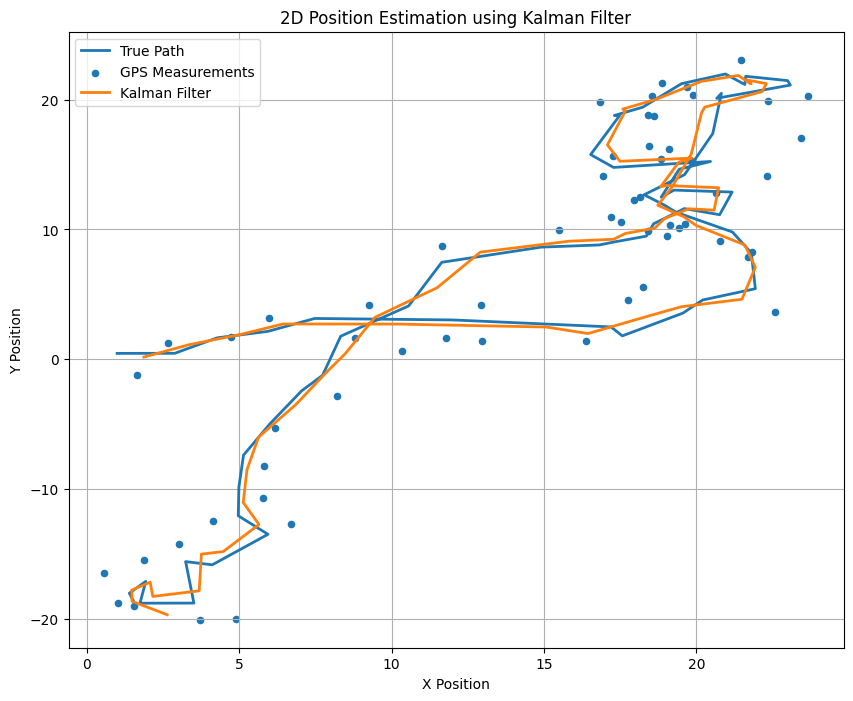

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Simulation Parameters
# -----------------------------
dt = 1.0
num_steps = 60

# -----------------------------
# State Transition Matrix
# -----------------------------
A = np.array([
    [1, 0, dt, 0],
    [0, 1, 0, dt],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])

# -----------------------------
# Measurement Matrix
# -----------------------------
H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

# -----------------------------
# Process Noise Matrix
# -----------------------------
G = np.array([
    [0.5*dt**2, 0],
    [0, 0.5*dt**2],
    [dt, 0],
    [0, dt]
])

# Process Noise Covariance
Sigma_p = np.array([
    [0.1, 0],
    [0, 0.1]
])

Q = G @ Sigma_p @ G.T

# Measurement Noise Covariance
R = np.array([
    [4, 0],
    [0, 4]
])

# -----------------------------
# Initial State
# -----------------------------
x = np.array([
    [0],
    [0],
    [1],
    [0.5]
])

P = np.eye(4)

# -----------------------------
# Store Results
# -----------------------------
true_positions = []
measurements = []
filtered_positions = []

# -----------------------------
# Generate Data and Filter
# -----------------------------
for i in range(num_steps):

    # True Motion
    process_noise = G @ np.random.multivariate_normal(
        [0, 0], Sigma_p
    ).reshape(2,1)

    x = A @ x + process_noise

    true_positions.append(x[:2].flatten())

    # GPS Measurement
    measurement_noise = np.random.multivariate_normal(
        [0,0], R
    ).reshape(2,1)

    z = H @ x + measurement_noise

    measurements.append(z.flatten())

    # Prediction Step
    x_pred = A @ x
    P_pred = A @ P @ A.T + Q

    # Innovation
    y = z - H @ x_pred

    # Innovation Covariance
    S = H @ P_pred @ H.T + R

    # Kalman Gain
    K = P_pred @ H.T @ np.linalg.inv(S)

    # Update Step
    x = x_pred + K @ y

    P = (np.eye(4) - K @ H) @ P_pred

    filtered_positions.append(x[:2].flatten())

# -----------------------------
# Convert to Arrays
# -----------------------------
true_positions = np.array(true_positions)
measurements = np.array(measurements)
filtered_positions = np.array(filtered_positions)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10,8))

plt.plot(
    true_positions[:,0],
    true_positions[:,1],
    linewidth=2,
    label="True Path"
)

plt.scatter(
    measurements[:,0],
    measurements[:,1],
    s=20,
    label="GPS Measurements"
)

plt.plot(
    filtered_positions[:,0],
    filtered_positions[:,1],
    linewidth=2,
    label="Kalman Filter"
)

plt.xlabel("X Position")
plt.ylabel("Y Position")

plt.title("2D Position Estimation using Kalman Filter")

plt.legend()

plt.grid(True)

plt.show()